# Quality Control of AFM Force Spectroscopy Data with Variational Autoencoders


<a href="https://colab.research.google.com/github/JChonpca/ASAP/blob/CVAE/tutorial/QC/QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook provides you with a complete code example that first trains a variational autoencoder on AFM force spectroscopy curves in a self-supervised way; then constructs a latent space where the AFM curves are placed; and finally uses the latent space to check the quality of the AFM curves.


In [1]:
# Uncomment codes in this cell if using Colab/Kaggle.

# !pip install deeplay ipympl   
# from google.colab import output
# output.enable_custom_widget_manager()

## 1. Load the 3T3 Cell Dataset

### 1.1. Download the 3T3 Cell Dataset

Download the 3T3_cell_dataset into the `3T3_cell_dataset` local folder.

This dataset contains AFM force spectroscopy collected using a culture of 3T3 cells (a widely used, immortalized mouse fibroblast cell line derived from Swiss albino mouse embryos).

This dataset contains
- `approach` is a folder with the approach curves, as files `0.npy`, `1.npy`, etc.
- `retraction` is a folder with the retraction curves, paired with the approach curves.
- `label.npy` is the label file for the approach curves: `0` is for good curves, `1` is for bad curves, and `-1` is for curves of unknown quality.
- `contact_point.npy` contains the contact points for each curve.

In [1]:
import os

if not os.path.exists("3t3_cell_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/3t3_cell_dataset")

### 1.2. Explore the 3T3 Cell Dataset

Load the 3T3 cell dataset ...

In [2]:
from pathlib import Path
import numpy as np

# Load the approach curves
approach_path = Path.cwd() / "3t3_cell_dataset" / "approach"
approach_files = sorted(approach_path.glob("*.npy"), key=lambda f: int(f.stem))
approach_curves = [np.load(f) for f in approach_files]

# Load the retraction curves
retract_path = Path.cwd() / "3t3_cell_dataset" / "retraction"
retract_files = sorted(retract_path.glob("*.npy"), key=lambda f: int(f.stem))
retract_curves = [np.load(f) for f in retract_files]

# Load the labels
labels = np.load(Path.cwd() / "3t3_cell_dataset" / "label.npy")

# Load the contact points
contactpoints = np.load(Path.cwd() / "3t3_cell_dataset" / "contact_point.npy")

... print the number of approach/retraction curves and labels ...

In [3]:
print(
    f"3T3 cell dataset:\n"
    f"- {len(approach_curves)} approach curves\n"
    f"- {len(retract_curves)} retraction curves\n"
    f"- {len(labels)} labels\n"
    f"- {len(contactpoints)} contact points"
)

3T3 cell dataset:
- 2548 approach curves
- 2548 retraction curves
- 2548 labels
- 2548 contact points


... calculate the length of each curve in the dataset ...

In [6]:
# Calculate the length of each curve
approach_curve_lengths = [curve.shape[0] for curve in approach_curves]
retract_curve_lengths = [curve.shape[0] for curve in retract_curves]

... and visualize the distribution (the lengths of the approach curves are usually shorter than the value set in the experiments, 3000, due to differences in topology across the cells).

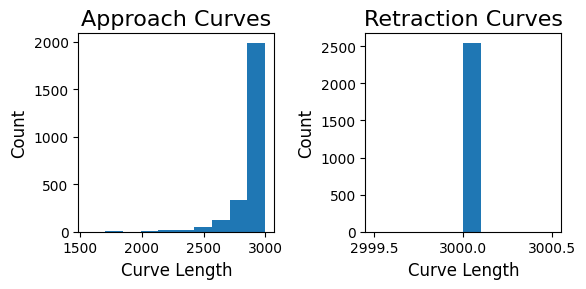

In [13]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=((6, 3)))

# Plot the length distribution of the approach curves
axs[0].hist(approach_curve_lengths)
axs[0].set_title("Approach Curves", fontsize=16)
axs[0].set_xlabel("Curve Length", fontsize=12)
axs[0].set_ylabel("Count", fontsize=12)

# Plot the length distribution of the retraction curves
axs[1].hist(retract_curve_lengths)
axs[1].set_title("Retraction Curves", fontsize=16)
axs[1].set_xlabel("Curve Length", fontsize=12)
axs[1].set_ylabel("Count", fontsize=12)
axs[1].ticklabel_format(axis="x", useOffset=False)

fig.tight_layout()
plt.show()

Finally, you can plot some paired approach/retraction curves, highlighting the the contact point.

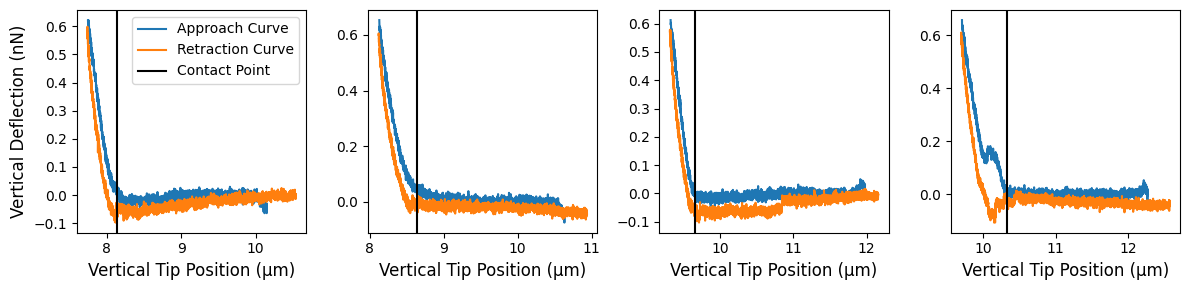

In [22]:
fig, axs = plt.subplots(1, 4, figsize=((12, 3)))

for idx, ax in enumerate(axs.ravel()):
    approach_curve = approach_curves[idx]
    retract_curve = retract_curves[idx]
    contactpoint = contactpoints[idx]

    ax.plot(approach_curve[:, 0], approach_curve[:,1], label="Approach Curve")

    ax.plot(retract_curve[:, 0], retract_curve[:,1], label="Retraction Curve")

    ax.axvline(contactpoint, c="k", label="Contact Point")

    ax.set_xlabel("Vertical Tip Position (µm)", fontsize=12)
    if idx == 0:
        ax.set_ylabel("Vertical Deflection (nN)", fontsize=12)
        ax.legend()

fig.tight_layout()
plt.show()

## 2. Quality Control of Approach Curves

### 2.1. Data Preprocessing

For approach curves, we downsample each curve to make the length align with the shortest one, and align the contact point ...

In [ ]:
# downsample the curve to get the same input size for VAE
downsampling_data = []
align_contactpoints = []
for indx in range(len(approach_curves)):
    sub_indices = np.linspace(0, approach_curves[indx].shape[0]-1, min(approach_curve_lengths))
    sub_indices = np.round(sub_indices).astype(int)
    downsampling_data.append(approach_curves[indx][sub_indices][:,1])
    idx = np.abs(approach_curves[indx][sub_indices][:,0] - contactpoints[indx]).argmin()
    align_contactpoints.append(idx/min(approach_curve_lengths))

... and normolized each curve to the range. 

In [9]:
# normalize each curve according to its max and min value
normolized_downsampling_data = []
for i in range(len(downsampling_data)):
    normolized_downsampling_data.append(
        (downsampling_data[i] - downsampling_data[i].min())
        / (downsampling_data[i].max() - downsampling_data[i].min())
    )

Then, we can plot some normalized curves.

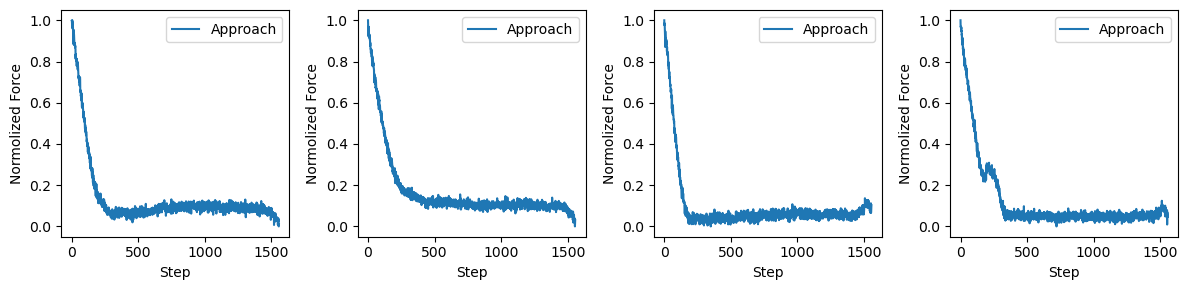

In [10]:
fig, axs = plt.subplots(1, 4, figsize=((12, 3)))
for idx, ax in enumerate(axs.ravel()):
    data_apporach_plot = normolized_downsampling_data[idx]
    ax.plot(data_apporach_plot[::-1], label=title_list[0])
    ax.set_xlabel("Step", fontsize=10)
    ax.set_ylabel("Normolized Force", fontsize=10)
    ax.ticklabel_format(axis="x", useOffset=False)
    ax.legend()
fig.tight_layout()
plt.show()

### 2.2. Define the Dataloader

Define a custom AFM dataset ...

In [11]:
import torch
import deeplay as dl

class AFMDataset(torch.utils.data.Dataset):
    """Dataset of AFM Force Spectroscopy."""

    def __init__(self, data, contact_point):
        """Initialize AFM dataset."""
        self.curves = np.array(data)
        self.contact_point = np.array(contact_point)

    def __len__(self):
        """Return number of curves."""
        return self.curves.shape[0]

    def __getitem__(self, idx):
        """Get next curve."""
        curve = torch.tensor(self.curves[idx]).float()
        contact_point = torch.tensor(self.contact_point[idx]).float()
        return [curve, curve, contact_point]

... and use it to create the train data and test data loaders.

In [ ]:
from sklearn.model_selection import train_test_split

# Randomly select the train and test data
train_x, test_x, label_train, label_test, contact_train, contact_test = train_test_split(
    normolized_downsampling_data, labels, align_contactpoints, test_size=0.2, random_state=577
)

# Randomly select the train and test dataset
train_dataloader = dl.DataLoader(
    AFMDataset(data=train_x, contact_point=contact_train),
    batch_size=10240,
)

test_dataloader = dl.DataLoader(
    AFMDataset(data=test_x, contact_point=contact_test),
    batch_size=10240,
)

### 2.3. Define the Autoencoders

Define the application module of variational autoencoder based on the multilayer perceptron ...

In [13]:
import lightning as L
import torch
import torch.nn as nn
from typing import Optional, Sequence, Callable, List
from deeplay.applications import Application
from deeplay.external import External, Optimizer, Adam


class ConditionalVariationalAutoEncoder(Application):

    last_channels: int
    latent_dim: int
    encoder: torch.nn.Module
    decoder: torch.nn.Module
    beta: float
    reconstruction_loss: torch.nn.Module
    metrics: list
    optimizer: Optimizer

    def __init__(
        self,
        last_channels: int,
        encoder: Optional[nn.Module] = None,
        decoder: Optional[nn.Module] = None,
        reconstruction_loss: Optional[Callable] = nn.BCELoss(reduction="sum"),
        latent_dim=int,
        beta=1,
        optimizer=None,
        **kwargs,
    ):
        self.encoder = encoder
        self.fc_mu = nn.Linear(
            last_channels,
            latent_dim,
        )
        self.fc_var = nn.Linear(
            last_channels,
            latent_dim,
        )
        self.fc_dec = nn.Linear(
            latent_dim + 1,
            last_channels,
        )
        self.decoder = decoder
        self.reconstruction_loss = reconstruction_loss or nn.BCELoss(reduction="sum")
        self.latent_dim = latent_dim
        self.beta = beta

        super().__init__(**kwargs)

        self.optimizer = optimizer or Adam(lr=1e-4)

        @self.optimizer.params
        def params(self):
            return self.parameters()

    def encode(self, x, c):
        
        if len(c.shape) == 1:
            c = c.unsqueeze(1)
    
        x = torch.cat([x, c], dim=1)
        x = self.encoder(x)
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)

        return mu, log_var

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps * std + mu

    def decode(self, z, c):
        if len(c.shape) == 1:
            c = c.unsqueeze(1)
    
        z = torch.cat([z, c], dim=1)
        x = self.fc_dec(z)
        x = self.decoder(x)
        return x
        
    def train_preprocess(self, batch):
        x, y, c = batch
        x = self._maybe_to_channel_first(x)
        y = self._maybe_to_channel_first(y)
        c = self._maybe_to_channel_first(c)
        return x, y, c

    val_preprocess = train_preprocess
    test_preprocess = train_preprocess
    
    def training_step(self, batch, batch_idx):
        x, y, c = self.train_preprocess(batch)
        y_hat, mu, log_var, z = self(x, c)
        rec_loss, KLD = self.compute_loss(y_hat, y, mu, log_var)
        tot_loss = rec_loss + self.beta * KLD
        loss = {"rec_loss": rec_loss, "KL": KLD, "total_loss": tot_loss}
        for name, v in loss.items():
            self.log(
                f"train_{name}",
                v,
                on_step=True,
                on_epoch=True,
                prog_bar=True,
                logger=True,
            )
        return tot_loss

    def test_step(self, batch, batch_idx):

        x, y, c  = self.test_preprocess(batch)
        y_hat, mu, log_var, z = self(x, c)
        rec_loss, KLD = self.compute_loss(y_hat, y, mu, log_var)
        tot_loss = rec_loss + self.beta * KLD
        loss = {"rec_loss": rec_loss, "KL": KLD, "total_loss": tot_loss}
        for name, v in loss.items():
            self.log(
                f"test_{name}",
                v,
                on_step=True,
                on_epoch=True,
                prog_bar=True,
                logger=True,
            )
        return tot_loss
        

    def validation_step(self, batch, batch_idx):

        x, y, c = self.val_preprocess(batch)
        y_hat, mu, log_var, z = self(x, c)
        rec_loss, KLD = self.compute_loss(y_hat, y, mu, log_var)
        tot_loss = rec_loss + self.beta * KLD
        loss = {"rec_loss": rec_loss, "KL": KLD, "total_loss": tot_loss}
        for name, v in loss.items():
            self.log(
                f"val_{name}",
                v,
                on_step=True,
                on_epoch=True,
                prog_bar=True,
                logger=True,
            )
        return tot_loss
    
    def compute_loss(self, y_hat, y, mu, log_var):
        rec_loss = self.reconstruction_loss(y_hat, y)
        KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        return rec_loss, KLD

    def forward(self, x, c):
        mu, log_var = self.encode(x, c)
        z = self.reparameterize(mu, log_var)
        y_hat = self.decode(z, c)
        return y_hat, mu, log_var, z


... use it to instantiation the model.

In [ ]:
encoder_block = dl.MultiLayerPerceptron(
    in_features=min(approach_curve_lengths)+1,
    hidden_features=[512, 256, 128, 64],
    out_features=64,
)

encoder_block.blocks[0].activated(nn.Tanh)
encoder_block.blocks[1].activated(nn.Tanh)
encoder_block.blocks[2].activated(nn.Tanh)
encoder_block.blocks[3].activated(nn.Tanh)
encoder_block.blocks[4].activated(nn.Tanh)

decoder_block = dl.MultiLayerPerceptron(
    in_features=64,
    hidden_features=[64, 128, 256, 512],
    out_features=min(approach_curve_lengths),
)

decoder_block.blocks[0].activated(nn.Tanh)
decoder_block.blocks[1].activated(nn.Tanh)
decoder_block.blocks[2].activated(nn.Tanh)
decoder_block.blocks[3].activated(nn.Tanh)
decoder_block.blocks[4].activated(nn.Sigmoid)

vae = ConditionalVariationalAutoEncoder(
    last_channels=64,
    encoder=encoder_block,
    decoder=decoder_block,
    reconstruction_loss=torch.nn.MSELoss(reduction="sum"),
    beta=1,
    latent_dim=2,
).create()

print(vae)

ConditionalVariationalAutoEncoder(
  (encoder): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Linear(in_features=1558, out_features=512, bias=True)
        (activation): Tanh()
      )
      (1): LinearBlock(
        (layer): Linear(in_features=512, out_features=256, bias=True)
        (activation): Tanh()
      )
      (2): LinearBlock(
        (layer): Linear(in_features=256, out_features=128, bias=True)
        (activation): Tanh()
      )
      (3): LinearBlock(
        (layer): Linear(in_features=128, out_features=64, bias=True)
        (activation): Tanh()
      )
      (4): LinearBlock(
        (layer): Linear(in_features=64, out_features=64, bias=True)
        (activation): Tanh()
      )
    )
  )
  (fc_mu): Linear(in_features=64, out_features=2, bias=True)
  (fc_var): Linear(in_features=64, out_features=2, bias=True)
  (fc_dec): Linear(in_features=3, out_features=64, bias=True)
  (decoder): MultiLayerPerceptron(
    (blocks): LayerLis

### 2.4. Train the Autoencoders

Define trainner with the callback function to save the best model by monitoring the validation loss.

In [15]:
from pytorch_lightning.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    monitor="val_total_loss",
    mode="min",
    save_top_k=1
)

vae_trainer = dl.Trainer(max_epochs=10000, accelerator="auto", callbacks=[checkpoint_callback])

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You can also load the trained model from our side.

In [16]:
# Uncomment if you don't want to train

#best_model_path = os.path.join(os.getcwd(), "Model", "3t3_qc", "epoch=6886-step=6887.ckpt")
#print(f"Loading the model from DeepTrack Team at {best_model_path}")
#vae.load_state_dict(torch.load(best_model_path, map_location="cpu")["state_dict"])
#best_model = vae

Loading the model from DeepTrack Team at /Users/iluvatar/Desktop/Bruker_QC/personalrepo/ASAP/tutorial/QC/Model/3t3_qc/epoch=6886-step=6887.ckpt


Or train the neural network regressor with the AFM force spectroscopy data ...

In [ ]:
vae_trainer.fit(vae, train_dataloader, test_dataloader)

... and load the best model from the callback function.

In [29]:
print(f"The best model is save at {checkpoint_callback.best_model_path}")
best_model = ConditionalVariationalAutoEncoder.load_from_checkpoint(checkpoint_callback.best_model_path)

The best model is save at /Users/iluvatar/Desktop/Bruker_QC/personalrepo/ASAP/tutorial/QC/lightning_logs/version_7/checkpoints/epoch=6886-step=6887.ckpt


### 2.5. Evaluate the Best Model

Evaluate the model in both train dataset and test dataset.

In [17]:
print("The performance in Trainset")
_ = vae_trainer.test(best_model, train_dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


The performance in Trainset


/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Testing: |                                                                                                    …

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_KL_epoch       │     271.2106018066406     │
│    test_rec_loss_epoch    │     2198.762451171875     │
│   test_total_loss_epoch   │     2469.97314453125      │
└───────────────────────────┴───────────────────────────┘

In [18]:
print("The performance in Testset")
_ = vae_trainer.test(best_model, test_dataloader)

The performance in Testset


Testing: |                                                                                                    …

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_KL_epoch       │     56.41820526123047     │
│    test_rec_loss_epoch    │     667.4779052734375     │
│   test_total_loss_epoch   │     723.8961181640625     │
└───────────────────────────┴───────────────────────────┘

The best model can used to generate the reconstruction curves too.

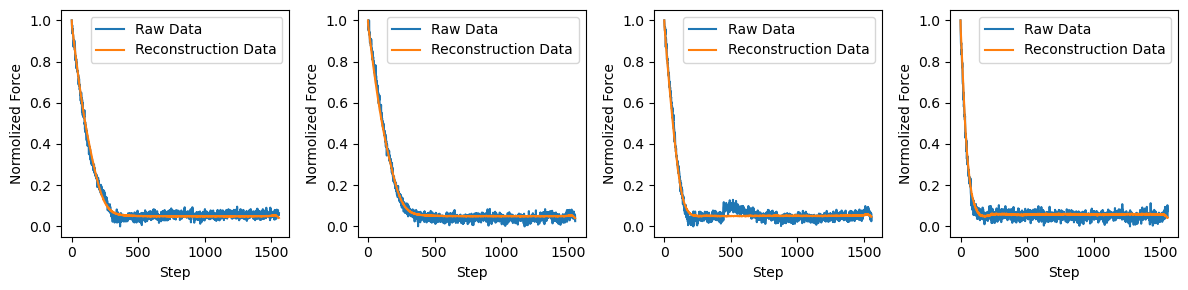

In [19]:
# put the model under eval mode
best_model.eval()

# collect the decoding curves and encoding latent space in the test dataset
with torch.no_grad():
    for indx, batch in enumerate(test_dataloader):
        x, y, c = batch
        y_hat, mu, logvar, _ = best_model(x,c)
        if indx == 0:
            y_list = y
            y_hat_list = y_hat
            mu_list = mu
            log_var_list = logvar
        else:
            y_list = torch.vstack([y_list,y])
            y_hat_list = torch.vstack([y_hat_list,y_hat])
            mu_list = torch.vstack([mu_list,mu])
            log_var_list = torch.vstack([log_var_list,logvar])

# plot the comparison between the reconstruction and the originals
fig, axs = plt.subplots(1, 4, figsize=((12, 3)))
for idx, ax in enumerate(axs.ravel()):
    data_apporach_plot_raw = y_list[idx].numpy()
    ax.plot(data_apporach_plot_raw[::-1], label="Raw Data")
    data_apporach_plot_reconstruct = y_hat_list[idx].numpy()
    ax.plot(data_apporach_plot_reconstruct[::-1], label="Reconstruction Data")    
    ax.set_xlabel("Step", fontsize=10)
    ax.set_ylabel("Normolized Force", fontsize=10)
    ax.ticklabel_format(axis="x", useOffset=False)
    ax.legend()
fig.tight_layout()
plt.show()

### 2.6. Check the Latent Space 

Collect the decoding curves and encoding latent space in all curves ...

In [ ]:
# Construct the 
all_dataloader = dl.DataLoader(
    AFMDataset(data=normolized_downsampling_data, contact_point=contactpoints),
    batch_size=10240,
    shuffle=False
)

# collect the decoding curves and encoding latent space in the test dataset
with torch.no_grad():
    for indx, batch in enumerate(all_dataloader):
        x, y, c = batch
        y_hat, mu, logvar, _ = best_model(x, c)
        if indx == 0:
            x_list = x
            y_list = y
            y_hat_list = y_hat
            mu_list = mu
            log_var_list = logvar
        else:
            x_list = torch.vstack([x_list,x])
            y_list = torch.vstack([y_list,y])
            y_hat_list = torch.vstack([y_hat_list,y_hat])
            mu_list = torch.vstack([mu_list,mu])
            log_var_list = torch.vstack([log_var_list,logvar])

# Transfer them into Numpy array
x_list = x_list.numpy()
y_list = y_list.numpy()
y_hat_list = y_hat_list.numpy()
mu_list = mu_list.numpy()
log_var_list = log_var_list.numpy()

... and check the good/bad curves in the latent space generated by TSNE with the provided label ...

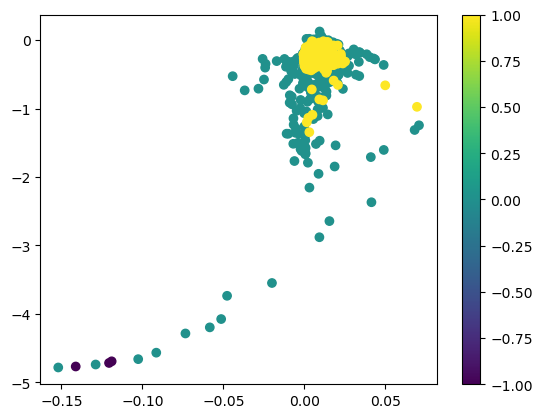

In [ ]:
plt.scatter(log_var_list[:,0],log_var_list[:,1], c=labels)
plt.colorbar()

... and play with weight.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

x = log_var_list[:, 0]
y = log_var_list[:, 1]
curves = x_list
x_curve = np.linspace(0, curves.shape[1], curves.shape[1])

colors = ["red", "green", "orange"]
marker_colors = [colors[c] for c in labels]

fig = make_subplots(
    rows=1, cols=2, subplot_titles=("Embedding Space", "Corresponding Curve")
)

scatter = go.Scatter(
    x=x, y=y, mode="markers", marker=dict(size=10, color=marker_colors), name="points"
)
fig.add_trace(scatter, row=1, col=1)

curve = go.Scatter(x=[], y=[], mode="lines", line=dict(color="red"), name="curve")
fig.add_trace(curve, row=1, col=2)

selected_marker = go.Scatter(
    x=[],
    y=[],
    mode="markers",
    marker=dict(size=10, symbol="x", color="black", line=dict(width=2)),
    name="selected",
)
fig.add_trace(selected_marker, row=1, col=1)

fig_widget = go.FigureWidget(fig)
fig_widget.update_layout(width=900, height=400)


def update_curve(trace, points, selector):
    if points.point_inds:
        idx = points.point_inds[0]
        with fig_widget.batch_update():

            fig_widget.data[1].x = x_curve
            fig_widget.data[1].y = curves[idx][::-1]
            fig_widget.layout.annotations[1].text = f"Curve {idx}"

            fig_widget.data[2].x = [x[idx]]
            fig_widget.data[2].y = [y[idx]]


fig_widget.data[0].on_click(update_curve)

display(fig_widget)

FigureWidget({
    'data': [{'marker': {'color': [red, red, red, ..., orange, orange, orange],
                         'size': 10},
              'mode': 'markers',
              'name': 'points',
              'type': 'scatter',
              'uid': '11d702a1-3f09-41fe-b9d9-1ae4a6181446',
              'x': {'bdata': ('krgqOx6GKjwzWdM6MR09O8ezozteNC' ... 'u6WuQ70xPGOjb29r0SjhC+zKjzvQ=='),
                    'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': ('GIq2vTuOeD3fXI++C9BqvlMS9b72Vf' ... '7Rvl6+nbievtXtlsD8k5jAUSiWwA=='),
                    'dtype': 'f4'},
              'yaxis': 'y'},
             {'line': {'color': 'red'},
              'mode': 'lines',
              'name': 'curve',
              'type': 'scatter',
              'uid': '6da065b3-c464-432d-88ef-e4b7173d3b7c',
              'x': [],
              'xaxis': 'x2',
              'y': [],
              'yaxis': 'y2'},
             {'marker': {'color': 'black', 'line': {'width': 2}, 'size': 1